# Signature Transformations Exploration

This notebook explores various path embeddings and signature transformations on financial time series data.

**Topics covered:**
- Different path embedding configurations (log_price, log_return, rolling features)
- Signature computation with various parameters (degree, time_aug, lead_lag)
- Visualization and comparison of feature dimensions
- Analysis of signature features for trading data

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Add parent directory to path to import rl module
sys.path.insert(0, str(Path().resolve().parent))

from rl.features.signature import PathBuilder, LogSigTransformer

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

✓ Imports successful
PyTorch version: 2.9.1
Device: CPU


## 2. Load and Prepare Data

In [2]:
# Load Bitcoin historical data
data_path = Path().resolve().parent / "data" / "Bitcoin History 2010-2024.csv"
df = pd.read_csv(data_path)

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (4955, 7)

Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

First few rows:


,Date,Price,Open,High,Low,Vol.,Change %
0,"Feb 09, 2024","47,545.4","45,293.3","47,710.2","45,254.2",86.85K,4.97%
1,"Feb 08, 2024","45,293.3","44,346.2","45,579.2","44,336.4",66.38K,2.15%
2,"Feb 07, 2024","44,339.8","43,088.4","44,367.9","42,783.5",48.57K,2.91%
3,"Feb 06, 2024","43,087.7","42,697.6","43,375.5","42,566.8",33.32K,0.91%
4,"Feb 05, 2024","42,697.2","42,581.4","43,532.2","42,272.5",39.26K,0.27%


Sample window size: 100
Price range: $34718.70 - $47545.40


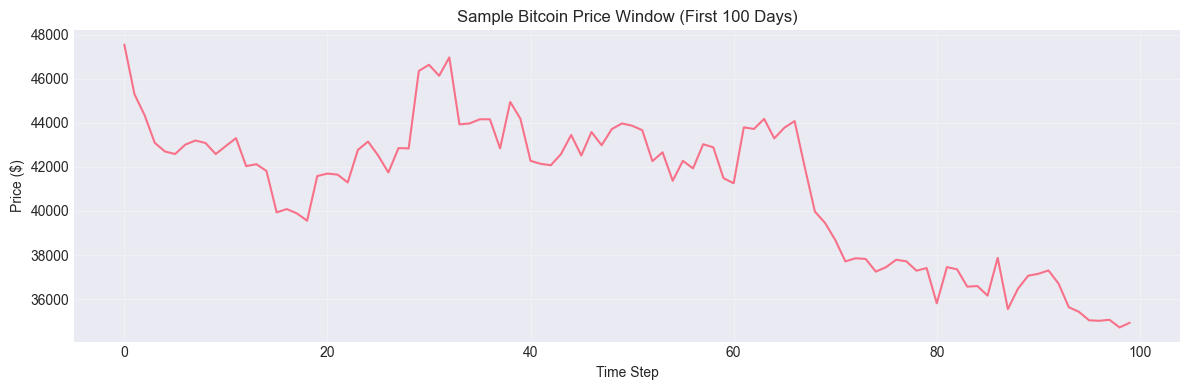

In [3]:
# Extract close prices and prepare sample windows
# Clean the 'Price' column by removing commas and converting to float
close_prices = df['Price'].str.replace(',', '').astype(float).values

# Create a sample window for exploration (e.g., 100 timesteps)
window_size = 100
sample_window = close_prices[:window_size]

print(f"Sample window size: {len(sample_window)}")
print(f"Price range: ${sample_window.min():.2f} - ${sample_window.max():.2f}")

# Visualize the sample window
plt.figure(figsize=(12, 4))
plt.plot(sample_window)
plt.title("Sample Bitcoin Price Window (First 100 Days)")
plt.xlabel("Time Step")
plt.ylabel("Price ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Path Embedding Configurations

The `PathBuilder` class creates multi-dimensional paths from price data using different components:
- **log_price**: Log-transformed relative prices
- **log_return**: Log returns (price differences in log space)
- **rolling_mean**: Moving average of returns
- **rolling_vol**: Rolling volatility (standard deviation)

In [4]:
# Define various embedding configurations to test
embedding_configs = {
    "price_only": {
        "embedding": {"log_price": {}},
        "description": "Only relative log prices"
    },
    "return_only": {
        "embedding": {"log_return": {}},
        "description": "Only log returns"
    },
    "price_return": {
        "embedding": {"log_price": {}, "log_return": {}},
        "description": "Price + Return (default)"
    },
    "price_return_vol": {
        "embedding": {"log_price": {}, "log_return": {}, "rolling_vol": {}},
        "description": "Price + Return + Volatility"
    },
    "full": {
        "embedding": {
            "log_price": {}, 
            "log_return": {}, 
            "rolling_mean": {"window": 5}, 
            "rolling_vol": {"window": 5}
        },
        "description": "All features (Price, Return, MA, Vol)"
    },
}

print("Embedding configurations to explore:")
for name, config in embedding_configs.items():
    print(f"  • {name}: {config['description']}")

Embedding configurations to explore:
  • price_only: Only relative log prices
  • return_only: Only log returns
  • price_return: Price + Return (default)
  • price_return_vol: Price + Return + Volatility
  • full: All features (Price, Return, MA, Vol)


In [5]:
# Build paths using different embedding configurations
paths = {}

for name, config in embedding_configs.items():
    builder = PathBuilder(
        embedding=config["embedding"],
        rolling_mean_window=5,
        device="cpu",
        dtype="float32"
    )
    path = builder.build(sample_window)
    paths[name] = path
    print(f"{name:20s} → Path shape: {path.shape} (dim={path.shape[1]})")

print(f"\n✓ Generated {len(paths)} different path embeddings")

price_only           → Path shape: torch.Size([100, 1]) (dim=1)
return_only          → Path shape: torch.Size([100, 1]) (dim=1)
price_return         → Path shape: torch.Size([100, 2]) (dim=2)
price_return_vol     → Path shape: torch.Size([100, 3]) (dim=3)
full                 → Path shape: torch.Size([100, 4]) (dim=4)

✓ Generated 5 different path embeddings


### Visualize Path Embeddings

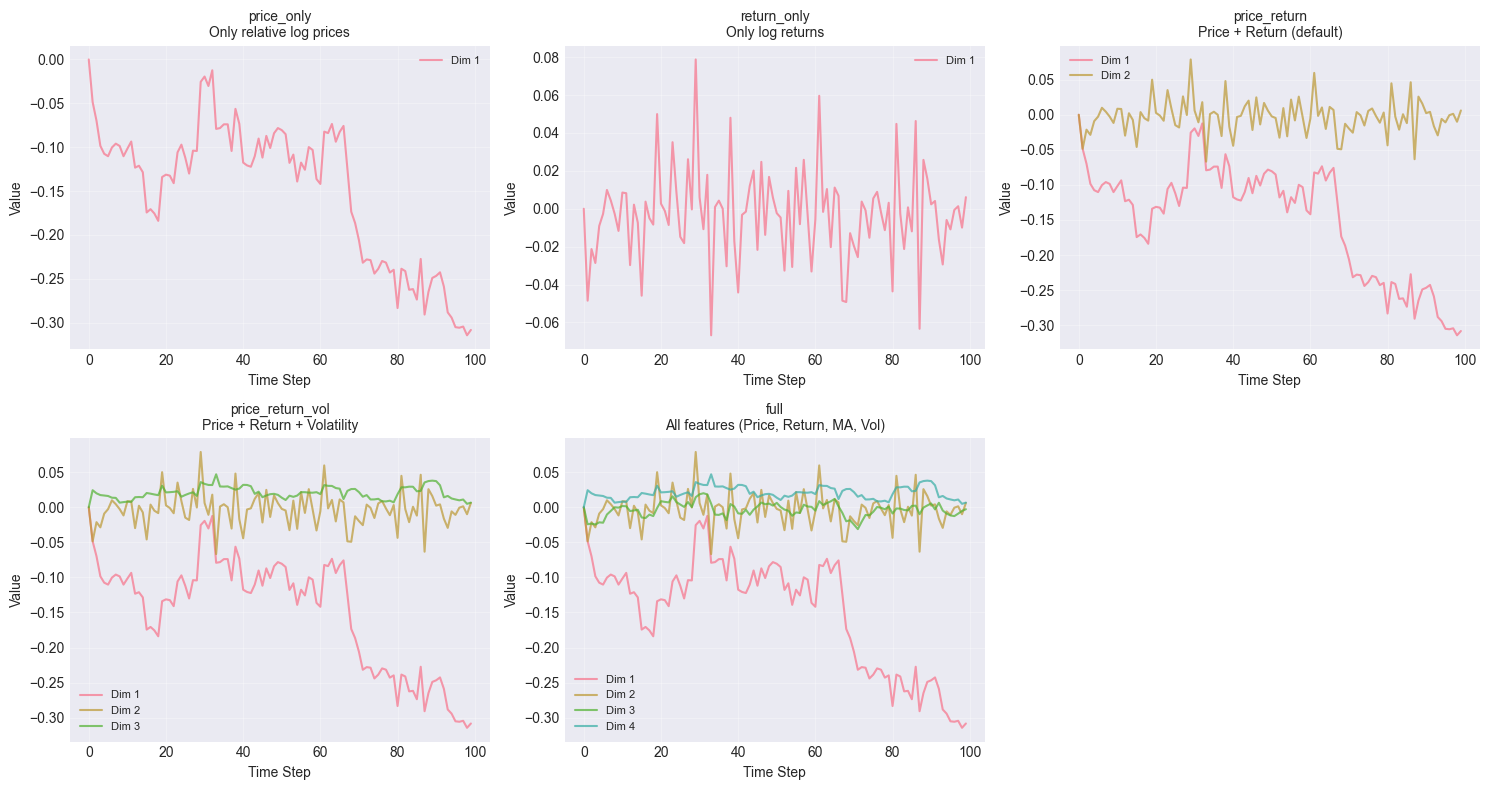

In [6]:
# Visualize different path embeddings
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (name, path) in enumerate(paths.items()):
    ax = axes[idx]
    path_np = path.cpu().numpy()
    
    # Plot each dimension
    for dim in range(path_np.shape[1]):
        ax.plot(path_np[:, dim], label=f'Dim {dim+1}', alpha=0.7)
    
    ax.set_title(f'{name}\n{embedding_configs[name]["description"]}', fontsize=10)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Value')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplot
if len(paths) < 6:
    for idx in range(len(paths), 6):
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 4. Signature Computation

The `LogSigTransformer` computes path signatures with various parameters:
- **degree**: Signature truncation level (higher = more features but exponential growth)
- **time_aug**: Add time dimension to path
- **lead_lag**: Apply lead-lag transformation (doubles path dimension)
- **method**: Computation method (1 = lyndon, faster for higher degrees)

In [7]:
# Define signature configurations to explore
signature_configs = [
    {"degree": 2, "time_aug": False, "lead_lag": False, "name": "deg2_basic"},
    {"degree": 3, "time_aug": False, "lead_lag": False, "name": "deg3_basic"},
    {"degree": 2, "time_aug": True, "lead_lag": False, "name": "deg2_timeaug"},
    {"degree": 2, "time_aug": False, "lead_lag": True, "name": "deg2_leadlag"},
    {"degree": 2, "time_aug": True, "lead_lag": True, "name": "deg2_timeaug_leadlag"},
    {"degree": 3, "time_aug": True, "lead_lag": False, "name": "deg3_timeaug"},
]

print("Signature configurations to explore:")
for config in signature_configs:
    print(f"  • {config['name']:25s} → deg={config['degree']}, "
          f"time_aug={config['time_aug']}, lead_lag={config['lead_lag']}")

Signature configurations to explore:
  • deg2_basic                → deg=2, time_aug=False, lead_lag=False
  • deg3_basic                → deg=3, time_aug=False, lead_lag=False
  • deg2_timeaug              → deg=2, time_aug=True, lead_lag=False
  • deg2_leadlag              → deg=2, time_aug=False, lead_lag=True
  • deg2_timeaug_leadlag      → deg=2, time_aug=True, lead_lag=True
  • deg3_timeaug              → deg=3, time_aug=True, lead_lag=False


In [8]:
# Choose a sample path for signature computation (price + return embedding)
sample_path = paths["price_return"]
base_dim = sample_path.shape[1]

print(f"Using path: price_return (shape: {sample_path.shape})")
print(f"Base dimension: {base_dim}\n")

# Compute signatures with different configurations
signatures = {}

for config in signature_configs:
    transformer = LogSigTransformer(
        degree=config["degree"],
        method=1,
        time_aug=config["time_aug"],
        lead_lag=config["lead_lag"],
        base_dim=base_dim,
        device="cpu",
        dtype="float32"
    )
    
    # Compute signature
    sig = transformer.transform(sample_path)
    signatures[config["name"]] = sig
    
    expected_dim = transformer.obs_dim(base_dim)
    print(f"{config['name']:25s} → Signature dim: {sig.shape[0]:4d} (expected: {expected_dim})")

print(f"\n✓ Computed {len(signatures)} different signatures")

Using path: price_return (shape: torch.Size([100, 2]))
Base dimension: 2

deg2_basic                → Signature dim:    7 (expected: 7)
deg3_basic                → Signature dim:   15 (expected: 15)
deg2_timeaug              → Signature dim:   13 (expected: 13)
deg2_leadlag              → Signature dim:   21 (expected: 21)
deg2_timeaug_leadlag      → Signature dim:   43 (expected: 43)
deg3_timeaug              → Signature dim:   40 (expected: 40)

✓ Computed 6 different signatures


### Visualize Signature Features

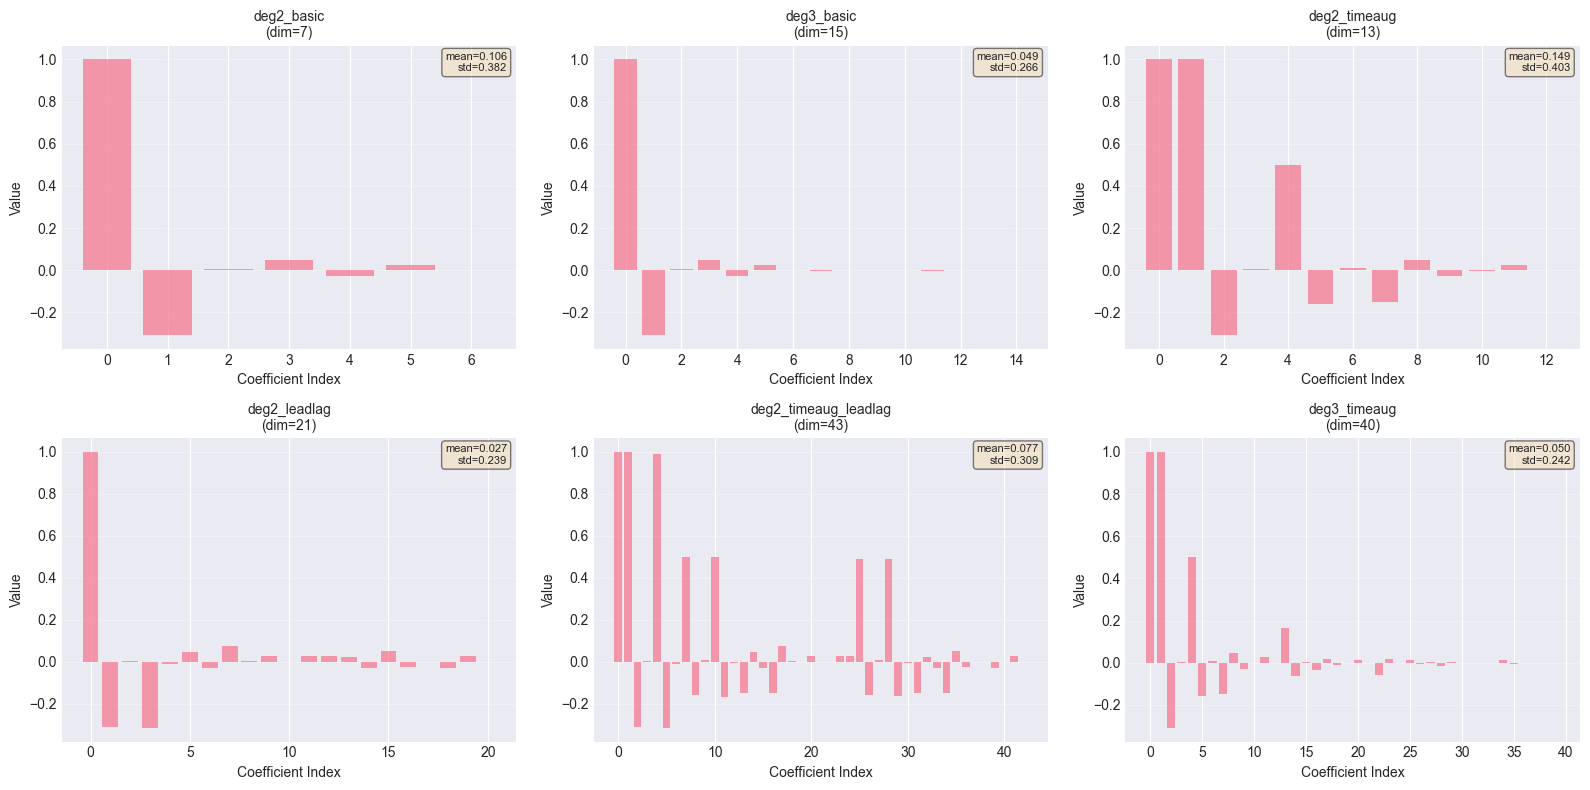

In [9]:
# Visualize signature coefficients as bar plots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, (name, sig) in enumerate(signatures.items()):
    ax = axes[idx]
    sig_np = sig.cpu().numpy()
    
    # Plot signature coefficients
    indices = np.arange(len(sig_np))
    ax.bar(indices, sig_np, alpha=0.7)
    
    ax.set_title(f'{name}\n(dim={len(sig_np)})', fontsize=10)
    ax.set_xlabel('Coefficient Index')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Show statistics
    ax.text(0.98, 0.98, f'mean={sig_np.mean():.3f}\nstd={sig_np.std():.3f}',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            fontsize=8)

plt.tight_layout()
plt.show()

## 5. Dimension Analysis

Compare how signature dimension grows with different parameters and base path dimensions.

In [10]:
# Analyze signature dimension growth for different configurations
results = []

# Test different degrees and base dimensions
degrees = [2, 3, 4, 5]
base_dims = [1, 2, 3, 4]

for degree in degrees:
    for base_dim in base_dims:
        for time_aug in [False, True]:
            for lead_lag in [False, True]:
                transformer = LogSigTransformer(
                    degree=degree,
                    time_aug=time_aug,
                    lead_lag=lead_lag,
                    base_dim=base_dim,
                    device="cpu"
                )
                sig_dim = transformer.obs_dim(base_dim)
                
                results.append({
                    'degree': degree,
                    'base_dim': base_dim,
                    'time_aug': time_aug,
                    'lead_lag': lead_lag,
                    'sig_dim': sig_dim
                })

results_df = pd.DataFrame(results)
print(f"Created dimension analysis table with {len(results_df)} configurations\n")
results_df.head(10)

Created dimension analysis table with 64 configurations



,degree,base_dim,time_aug,lead_lag,sig_dim
0,2,1,False,False,3
1,2,1,False,True,7
2,2,1,True,False,7
3,2,1,True,True,21
4,2,2,False,False,7
5,2,2,False,True,21
6,2,2,True,False,13
7,2,2,True,True,43
8,2,3,False,False,13
9,2,3,False,True,43


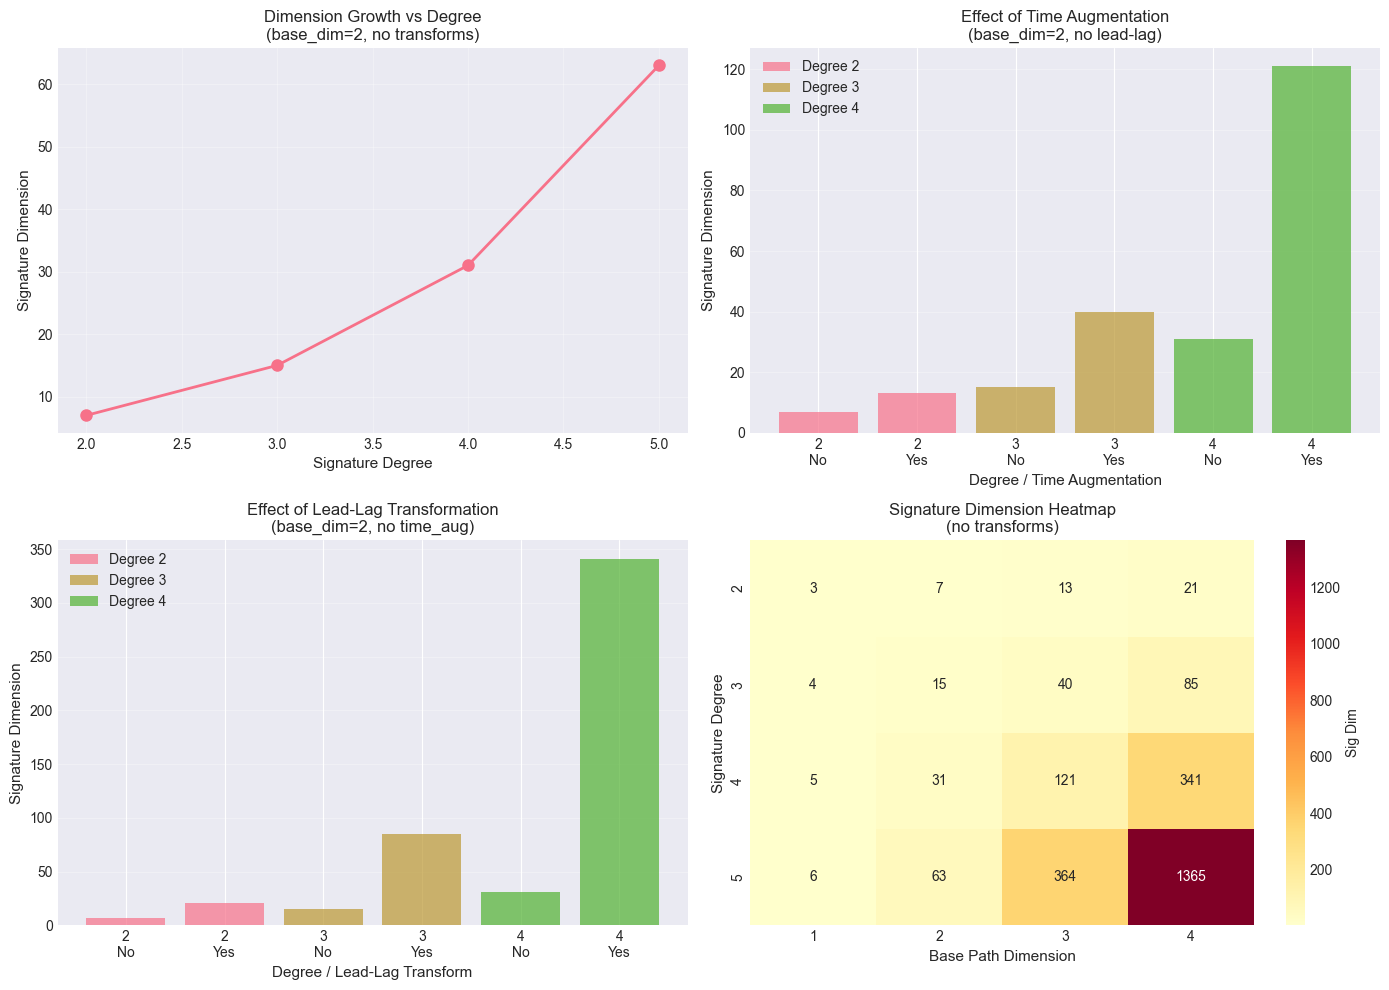

In [11]:
# Visualize dimension growth
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Signature dim vs degree (base_dim=2, no transforms)
ax = axes[0, 0]
subset = results_df[(results_df['base_dim'] == 2) & 
                     (~results_df['time_aug']) & 
                     (~results_df['lead_lag'])]
ax.plot(subset['degree'], subset['sig_dim'], 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Signature Degree', fontsize=11)
ax.set_ylabel('Signature Dimension', fontsize=11)
ax.set_title('Dimension Growth vs Degree\n(base_dim=2, no transforms)', fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 2: Effect of time_aug for different degrees
ax = axes[0, 1]
for degree in [2, 3, 4]:
    subset_no = results_df[(results_df['degree'] == degree) & 
                            (results_df['base_dim'] == 2) & 
                            (~results_df['time_aug']) & 
                            (~results_df['lead_lag'])]
    subset_yes = results_df[(results_df['degree'] == degree) & 
                             (results_df['base_dim'] == 2) & 
                             (results_df['time_aug']) & 
                             (~results_df['lead_lag'])]
    
    ax.bar([f'{degree}\nNo', f'{degree}\nYes'], 
           [subset_no['sig_dim'].values[0], subset_yes['sig_dim'].values[0]],
           alpha=0.7, label=f'Degree {degree}')

ax.set_xlabel('Degree / Time Augmentation', fontsize=11)
ax.set_ylabel('Signature Dimension', fontsize=11)
ax.set_title('Effect of Time Augmentation\n(base_dim=2, no lead-lag)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Effect of lead_lag for different degrees
ax = axes[1, 0]
for degree in [2, 3, 4]:
    subset_no = results_df[(results_df['degree'] == degree) & 
                            (results_df['base_dim'] == 2) & 
                            (~results_df['time_aug']) & 
                            (~results_df['lead_lag'])]
    subset_yes = results_df[(results_df['degree'] == degree) & 
                             (results_df['base_dim'] == 2) & 
                             (~results_df['time_aug']) & 
                             (results_df['lead_lag'])]
    
    ax.bar([f'{degree}\nNo', f'{degree}\nYes'], 
           [subset_no['sig_dim'].values[0], subset_yes['sig_dim'].values[0]],
           alpha=0.7, label=f'Degree {degree}')

ax.set_xlabel('Degree / Lead-Lag Transform', fontsize=11)
ax.set_ylabel('Signature Dimension', fontsize=11)
ax.set_title('Effect of Lead-Lag Transformation\n(base_dim=2, no time_aug)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Heatmap of sig_dim for degree vs base_dim (no transforms)
ax = axes[1, 1]
subset = results_df[(~results_df['time_aug']) & (~results_df['lead_lag'])]
pivot = subset.pivot(index='degree', columns='base_dim', values='sig_dim')
sns.heatmap(pivot, annot=True, fmt='g', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Sig Dim'})
ax.set_xlabel('Base Path Dimension', fontsize=11)
ax.set_ylabel('Signature Degree', fontsize=11)
ax.set_title('Signature Dimension Heatmap\n(no transforms)', fontsize=12)

plt.tight_layout()
plt.show()

## 6. End-to-End Pipeline Test

Test the complete pipeline: different embeddings → signature computation

In [12]:
# Create a comprehensive comparison matrix
comparison_results = []

# Test each embedding with each signature config
selected_embeddings = ["price_return", "price_return_vol", "full"]
selected_sig_configs = [
    {"degree": 2, "time_aug": False, "lead_lag": False},
    {"degree": 2, "time_aug": True, "lead_lag": False},
    {"degree": 3, "time_aug": False, "lead_lag": False},
]

for emb_name in selected_embeddings:
    path = paths[emb_name]
    base_dim = path.shape[1]
    
    for sig_config in selected_sig_configs:
        transformer = LogSigTransformer(
            degree=sig_config["degree"],
            time_aug=sig_config["time_aug"],
            lead_lag=sig_config["lead_lag"],
            base_dim=base_dim,
            device="cpu"
        )
        
        sig = transformer.transform(path)
        
        config_name = f"d{sig_config['degree']}"
        if sig_config['time_aug']:
            config_name += "_ta"
        if sig_config['lead_lag']:
            config_name += "_ll"
        
        comparison_results.append({
            'embedding': emb_name,
            'sig_config': config_name,
            'base_dim': base_dim,
            'sig_dim': len(sig),
            'sig_mean': sig.mean().item(),
            'sig_std': sig.std().item(),
            'sig_min': sig.min().item(),
            'sig_max': sig.max().item(),
        })

comparison_df = pd.DataFrame(comparison_results)
print("End-to-End Pipeline Results:\n")
comparison_df

End-to-End Pipeline Results:



,embedding,sig_config,base_dim,sig_dim,sig_mean,sig_std,sig_min,sig_max
0,price_return,d2,2,7,0.106210,0.412276,-0.308299,1.0
1,price_return,d2_ta,2,13,0.149329,0.418983,-0.308299,1.0
2,price_return,d3,2,15,0.049258,0.275481,-0.308299,1.0
3,price_return_vol,d2,3,13,0.057546,0.296622,-0.308299,1.0
4,price_return_vol,d2_ta,3,21,0.092976,0.332837,-0.308299,1.0
5,price_return_vol,d3,3,40,0.018595,0.166803,-0.308299,1.0
6,full,d2,4,21,0.035529,0.231568,-0.308299,1.0
7,full,d2_ta,4,31,0.062829,0.275373,-0.308299,1.0
8,full,d3,4,85,0.008726,0.114048,-0.308299,1.0


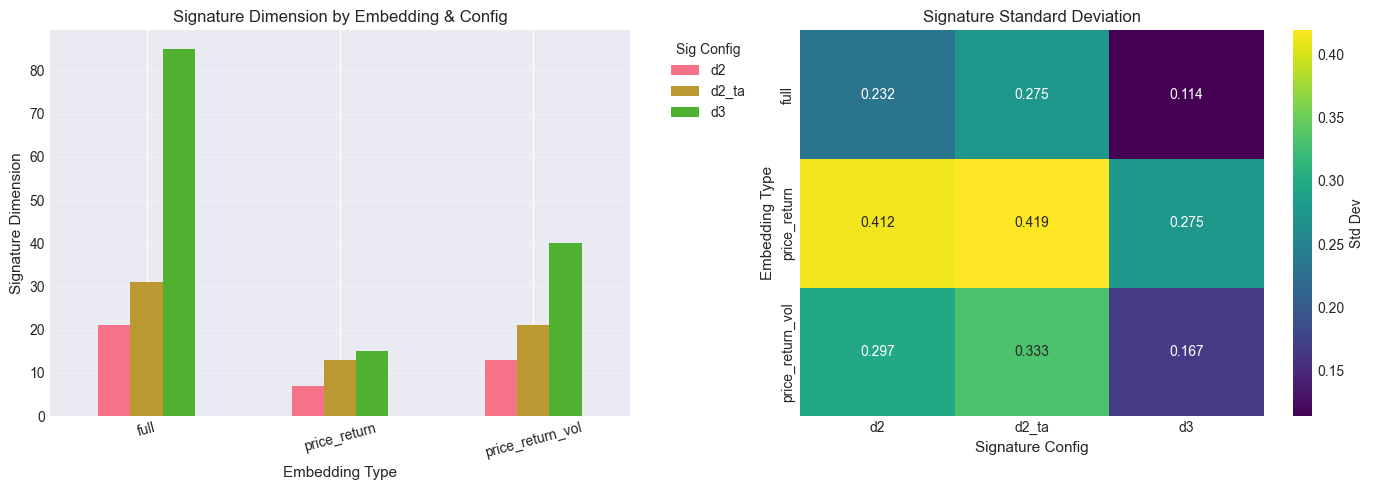

In [13]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Signature dimension comparison
ax = axes[0]
pivot = comparison_df.pivot(index='embedding', columns='sig_config', values='sig_dim')
pivot.plot(kind='bar', ax=ax, rot=15)
ax.set_xlabel('Embedding Type', fontsize=11)
ax.set_ylabel('Signature Dimension', fontsize=11)
ax.set_title('Signature Dimension by Embedding & Config', fontsize=12)
ax.legend(title='Sig Config', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Signature statistics heatmap
ax = axes[1]
pivot_std = comparison_df.pivot(index='embedding', columns='sig_config', values='sig_std')
sns.heatmap(pivot_std, annot=True, fmt='.3f', cmap='viridis', ax=ax, 
            cbar_kws={'label': 'Std Dev'})
ax.set_xlabel('Signature Config', fontsize=11)
ax.set_ylabel('Embedding Type', fontsize=11)
ax.set_title('Signature Standard Deviation', fontsize=12)

plt.tight_layout()
plt.show()

## 7. Multiple Windows Analysis

Analyze how signatures vary across different time windows in the data.

In [14]:
# Extract multiple windows from the dataset
n_windows = 10
window_size = 50
stride = 200  # Non-overlapping windows

windows = []
window_indices = []

for i in range(n_windows):
    start_idx = i * stride
    end_idx = start_idx + window_size
    if end_idx <= len(close_prices):
        windows.append(close_prices[start_idx:end_idx])
        window_indices.append((start_idx, end_idx))

print(f"Extracted {len(windows)} windows of size {window_size}")
print(f"Date range covered: {len(windows) * stride + window_size} days")

Extracted 10 windows of size 50
Date range covered: 2050 days


In [15]:
# Compute signatures for all windows
path_builder = PathBuilder(
    embedding={"log_price": {}, "log_return": {}},
    device="cpu"
)

sig_transformer = LogSigTransformer(
    degree=2,
    time_aug=True,
    lead_lag=False,
    base_dim=2,
    device="cpu"
)

window_signatures = []

for window in windows:
    path = path_builder.build(window)
    sig = sig_transformer.transform(path)
    window_signatures.append(sig.cpu().numpy())

window_signatures = np.array(window_signatures)
print(f"Computed signatures for all windows: {window_signatures.shape}")
print(f"  Shape: (n_windows={window_signatures.shape[0]}, sig_dim={window_signatures.shape[1]})")

Computed signatures for all windows: (10, 13)
  Shape: (n_windows=10, sig_dim=13)


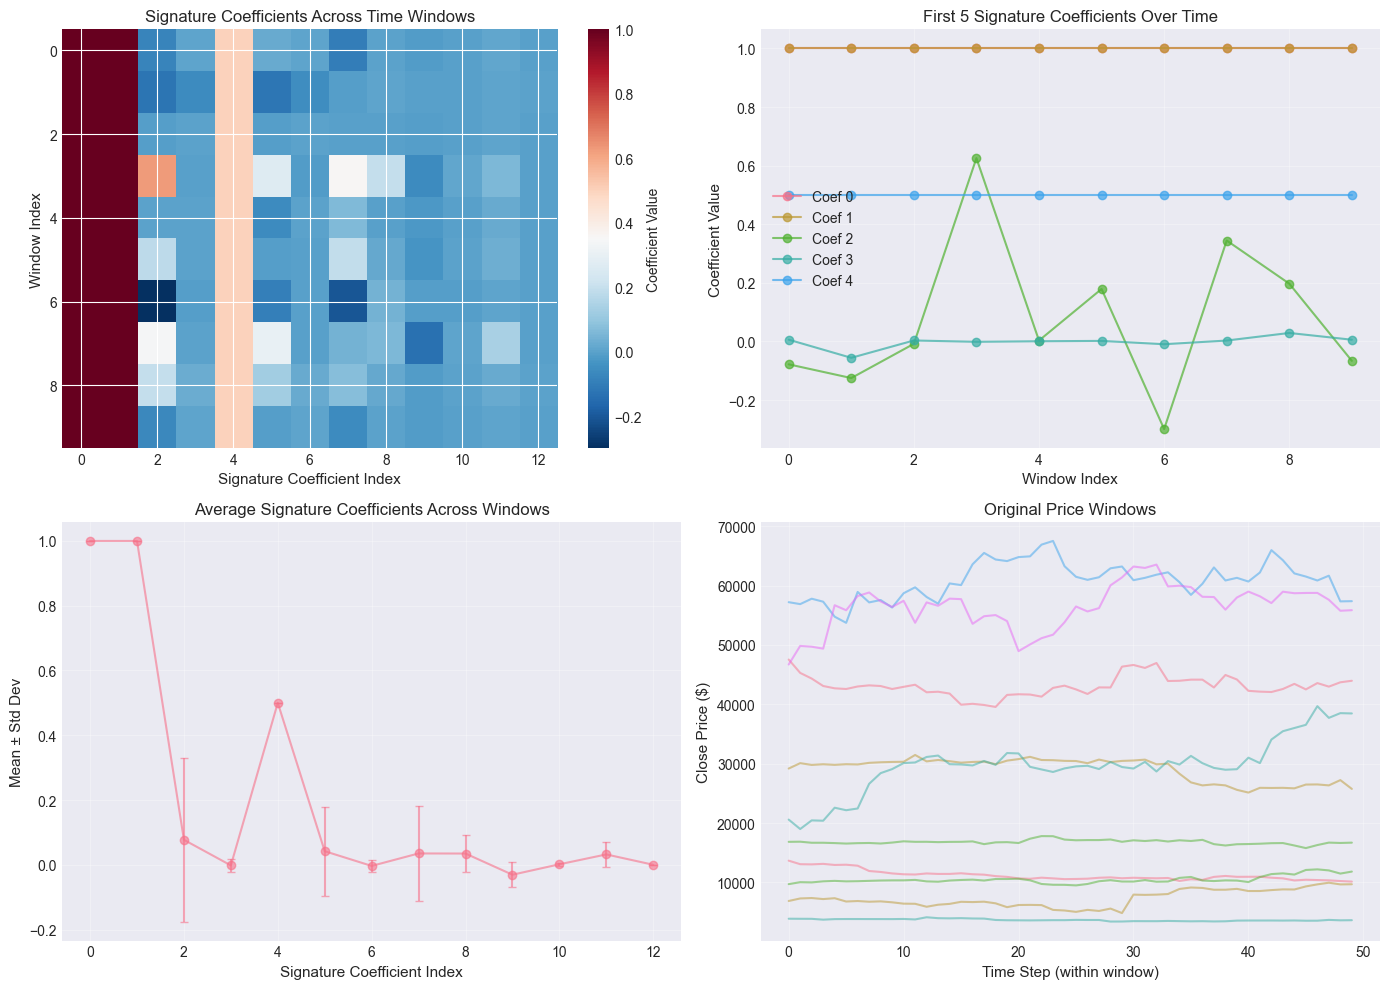

In [16]:
# Visualize signature variation across windows
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Heatmap of all signatures
ax = axes[0, 0]
im = ax.imshow(window_signatures, aspect='auto', cmap='RdBu_r', interpolation='nearest')
ax.set_xlabel('Signature Coefficient Index', fontsize=11)
ax.set_ylabel('Window Index', fontsize=11)
ax.set_title('Signature Coefficients Across Time Windows', fontsize=12)
plt.colorbar(im, ax=ax, label='Coefficient Value')

# Plot 2: First 5 signature coefficients over time
ax = axes[0, 1]
for i in range(min(5, window_signatures.shape[1])):
    ax.plot(window_signatures[:, i], 'o-', label=f'Coef {i}', alpha=0.7)
ax.set_xlabel('Window Index', fontsize=11)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_title('First 5 Signature Coefficients Over Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Mean and std of signatures
ax = axes[1, 0]
sig_means = window_signatures.mean(axis=0)
sig_stds = window_signatures.std(axis=0)
indices = np.arange(len(sig_means))
ax.errorbar(indices, sig_means, yerr=sig_stds, fmt='o-', alpha=0.6, capsize=3)
ax.set_xlabel('Signature Coefficient Index', fontsize=11)
ax.set_ylabel('Mean ± Std Dev', fontsize=11)
ax.set_title('Average Signature Coefficients Across Windows', fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 4: Price windows for context
ax = axes[1, 1]
for i, window in enumerate(windows):
    ax.plot(window, alpha=0.5, label=f'Window {i}' if i < 3 else '')
ax.set_xlabel('Time Step (within window)', fontsize=11)
ax.set_ylabel('Close Price ($)', fontsize=11)
ax.set_title('Original Price Windows', fontsize=12)
if len(windows) <= 3:
    ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Summary and Recommendations

### Key Findings:

1. **Embedding Configurations**:
   - Simple embeddings (1-2 dims) are fast but may miss important patterns
   - Full embeddings with volatility features provide richer information
   - Trade-off between feature richness and computational cost

2. **Signature Parameters**:
   - Degree 2-3 provides good balance for most applications
   - Time augmentation adds temporal information with modest dimension increase
   - Lead-lag transformations double the path dimension but capture co-movements

3. **Dimension Growth**:
   - Signature dimension grows exponentially with degree
   - For base_dim=2: deg2→6, deg3→14, deg4→30 (without transforms)
   - Time augmentation and lead-lag significantly increase dimension

4. **Recommendations for Trading**:
   - Start with `price_return` embedding + degree 2-3 with time_aug
   - Consider adding volatility features for more complex strategies
   - Monitor computational cost vs. information gain trade-off

## 9. Interactive Exploration

Try your own configurations here!

Custom Configuration Results:
  Window: days 500-580
  Path shape: torch.Size([80, 3])
  Signature dim: 85
  Signature stats: mean=0.0367, std=0.1618


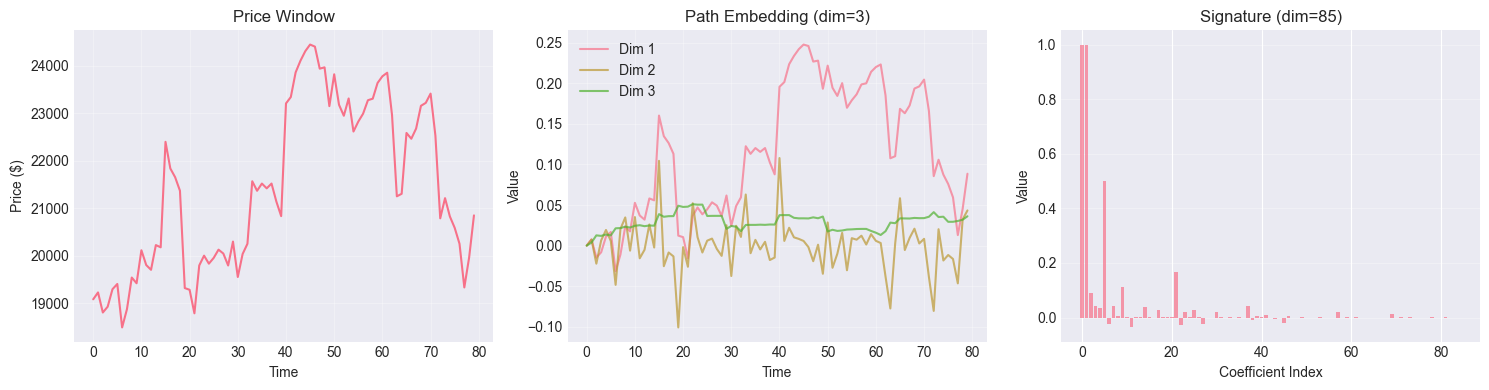

In [17]:
# === CUSTOMIZE THESE PARAMETERS ===
CUSTOM_EMBEDDING = {
    "log_price": {},
    "log_return": {},
    "rolling_vol": {"window": 10}
}
CUSTOM_DEGREE = 3
CUSTOM_TIME_AUG = True
CUSTOM_LEAD_LAG = False
WINDOW_START = 500
WINDOW_SIZE = 80
# ==================================

# Extract custom window
custom_window = close_prices[WINDOW_START:WINDOW_START + WINDOW_SIZE]

# Build path
custom_builder = PathBuilder(embedding=CUSTOM_EMBEDDING, device="cpu")
custom_path = custom_builder.build(custom_window)

# Compute signature
custom_transformer = LogSigTransformer(
    degree=CUSTOM_DEGREE,
    time_aug=CUSTOM_TIME_AUG,
    lead_lag=CUSTOM_LEAD_LAG,
    base_dim=custom_path.shape[1],
    device="cpu"
)
custom_sig = custom_transformer.transform(custom_path)

print(f"Custom Configuration Results:")
print(f"  Window: days {WINDOW_START}-{WINDOW_START + WINDOW_SIZE}")
print(f"  Path shape: {custom_path.shape}")
print(f"  Signature dim: {len(custom_sig)}")
print(f"  Signature stats: mean={custom_sig.mean():.4f}, std={custom_sig.std():.4f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original prices
axes[0].plot(custom_window)
axes[0].set_title('Price Window')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

# Path embedding
for dim in range(custom_path.shape[1]):
    axes[1].plot(custom_path[:, dim].cpu().numpy(), label=f'Dim {dim+1}', alpha=0.7)
axes[1].set_title(f'Path Embedding (dim={custom_path.shape[1]})')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Signature
axes[2].bar(range(len(custom_sig)), custom_sig.cpu().numpy(), alpha=0.7)
axes[2].set_title(f'Signature (dim={len(custom_sig)})')
axes[2].set_xlabel('Coefficient Index')
axes[2].set_ylabel('Value')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()